# Customer Churn Analysis


## Project Objective

Identify the factors that predict customer churn.

Dataset: IBM Telco Customer Churn

https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data$0

Target Variable: Churn

Models Evaluated:
- Logistic Regression
- Decision Tree
- Random Forest

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score

### Import required packages and dataset

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score,precision_score,recall_score

In [160]:
df=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vRQ2HLMt9sA5UY4sEYxzzMd9aAadQnVpn1gMjIda887Y_bLcl5OFkYUlS1N22FerA/pub?output=csv')

## Data Cleaning

### Show the first few records and data type

In [161]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Remove Missing Value and duplicates

In [163]:
#check for missing value
print("Number of missing value in this dataset:",df.isna().sum().sum(),'\n')
#becuase the number of missing value is small, we will drop them
df=df.dropna()
df=df.drop_duplicates()

Number of missing value in this dataset: 11 



### Recode category variables into numeric

In [164]:
df['gender']=np.where(df['gender']=='Male',1,0) # Male 1, Female 0
df['Partner']=np.where(df['Partner']=='Yes',1,0) # Yes 1, No 0
df['Dependents']=np.where(df['Dependents']=='Yes',1,0)
df['PhoneService']=np.where(df['PhoneService']=='Yes',1,0)
df['PaperlessBilling']=np.where(df['PaperlessBilling']=='Yes',1,0)
df['Churn']=np.where(df['Churn']=='Yes',1,0)

In [165]:
#create dummy variables for these columns as they are not binary
df=pd.get_dummies(df,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
              'StreamingTV','StreamingMovies','Contract','PaymentMethod'])

## Check the Data distribution

In [166]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


<Figure size 640x480 with 0 Axes>

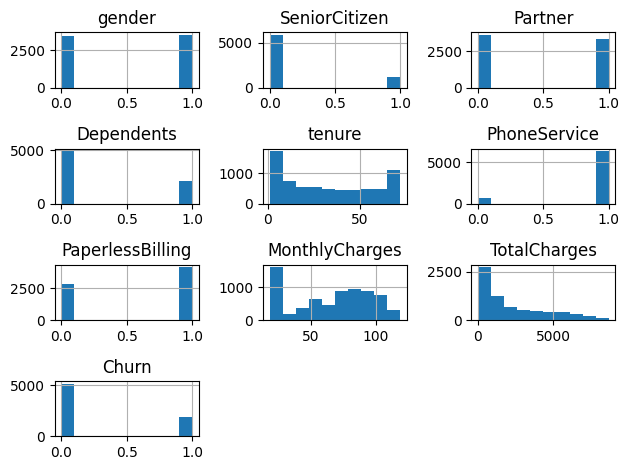

In [167]:
# show the distribution of the data
plt.figure()
df.hist()
plt.tight_layout()

## Outlier detection

In [168]:
#check outlier for these columns ternure, monthly charges and total charges

def outlier_detection(column_name):
  Q1=df[column_name].quantile(0.25)
  Q3=df[column_name].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  print(column_name)
  print("lower bound:",lower_bound,"upper bound:",upper_bound)
  print("Number of outliers in",column_name,"column:",sum(np.where(df[column_name]<lower_bound,1,(np.where(df[column_name]>upper_bound,1,0)))))
  print()

outlier_detection('tenure')
outlier_detection('MonthlyCharges')
outlier_detection('TotalCharges')

tenure
lower bound: -60.0 upper bound: 124.0
Number of outliers in tenure column: 0

MonthlyCharges
lower bound: -45.824999999999996 upper bound: 171.27499999999998
Number of outliers in MonthlyCharges column: 0

TotalCharges
lower bound: -4688.481250000001 upper bound: 8884.66875
Number of outliers in TotalCharges column: 0



## Reduce Data Dimensionality

In [169]:
df=df.drop(columns='customerID')

## Check correlation between features and correlation between features and target variable

In [170]:
correlation_result=df.corr()

In [171]:
i=0
result={}
while i< len(correlation_result.columns):
  #print(correlation_result.columns[i])
  if (correlation_result.iloc[0][i]>0.7) and (correlation_result.columns[i]!= correlation_result.iloc[0].name):
    print(correlation_result.columns[i],correlation_result.iloc[0][i])
    i=i+1
  else:
    i=i+1
    continue

/tmp/ipykernel_1777/913629056.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (correlation_result.iloc[0][i]>0.7) and (correlation_result.columns[i]!= correlation_result.iloc[0].name):


## Check the distribution of target variable

In [172]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


## Data Preparation

### Train Validation Split

In [173]:
Y=df['Churn']
X=df.drop(columns='Churn')
print(X.shape,Y.shape)

(7032, 40) (7032,)


In [174]:
X_train,X_val,Y_train,Y_val=train_test_split(
                                            X, Y,
                                            random_state=42,
                                            test_size=0.2,
                                            shuffle=True
)

In [175]:
print(X_train.shape,X_val.shape,Y_train.shape,Y_val.shape)

(5625, 40) (1407, 40) (5625,) (1407,)


# Pipeline

## Feature Selection

In [176]:
pipelines = []
pipelines.append(('ScaledDTC_under',Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomUnderSampler(random_state=42)),
 ('DTC',DecisionTreeClassifier(random_state=42))])))
pipelines.append(('ScaledDTC_over',Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomOverSampler(random_state=42)),
 ('DTC',DecisionTreeClassifier(random_state=42))])))

In [177]:
results=[]
for name, model in pipelines:
  model.fit(X_train,Y_train)
  predict=model.predict(X_val)
  accuracy=accuracy_score(Y_val,predict)
  f1=f1_score(Y_val,predict)
  precision=precision_score(Y_val,predict)
  recall=recall_score(Y_val,predict)
  results.append([name,accuracy,f1,precision,recall])

In [178]:
pd.DataFrame(results,columns=('Name','Accuracy Score','F1 Score','Precision','Recall'))

,Name,Accuracy Score,F1 Score,Precision,Recall
0,ScaledDTC_under,0.664534,0.513402,0.417785,0.665775
1,ScaledDTC_over,0.717839,0.503129,0.472941,0.537433


In [179]:
DTC=pipelines[0][1]
DTC.named_steps['DTC'].feature_importances_

array([0.01890848, 0.01032646, 0.02178893, 0.01723356, 0.08916795,
       0.00526923, 0.02409458, 0.17726302, 0.16975496, 0.00532999,
       0.        , 0.00743468, 0.00296451, 0.0165755 , 0.        ,
       0.04249254, 0.        , 0.00461335, 0.00528243, 0.00089445,
       0.00415252, 0.00295244, 0.        , 0.00818719, 0.00799329,
       0.        , 0.00805722, 0.00880372, 0.        , 0.0071941 ,
       0.00714815, 0.        , 0.0084025 , 0.25500937, 0.00401258,
       0.00445465, 0.00992476, 0.01303994, 0.01927542, 0.01199753])

In [180]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': DTC.named_steps['DTC'].feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [181]:
selected_features=list(importance[importance['Importance'] > 0]['Feature'])

In [182]:
Y=df['Churn']
X=df[selected_features]
print(X.shape,Y.shape)

(7032, 33) (7032,)


In [183]:
X_train,X_val,Y_train,Y_val=train_test_split(
                                            X, Y,
                                            random_state=42,
                                            test_size=0.2,
                                            shuffle=True
)

In [184]:
print(X_train.shape,X_val.shape,Y_train.shape,Y_val.shape)

(5625, 33) (1407, 33) (5625,) (1407,)


Features with zero importance in the Decision Tree model were removed to reduce dimensionality and focus on variables that contributed to prediction performance.

## Model selection

In [185]:
pipelines = []
pipelines.append(('ScaledLR_under', Pipeline([('Scaler', MinMaxScaler()),('Sampler',RandomUnderSampler(random_state=42)),
 ('LR', LogisticRegression(random_state=42))])))
pipelines.append(('ScaledLR_over', Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomOverSampler(random_state=42)),
 ('LR',LogisticRegression(random_state=42))])))
pipelines.append(('ScaledDTC_under',Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomUnderSampler(random_state=42)),
 ('DTC',DecisionTreeClassifier(random_state=42))])))
pipelines.append(('ScaledDTC_over',Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomOverSampler(random_state=42)),
 ('DTC',DecisionTreeClassifier(random_state=42))])))
pipelines.append(('ScaledRandomForest_under',Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomUnderSampler(random_state=42)),
('RandomForest',RandomForestClassifier(random_state=42))])))
pipelines.append(('ScaledRandomForest_over',Pipeline([('Scaler',MinMaxScaler()),('Sampler',RandomOverSampler(random_state=42)),
('RandomForest',RandomForestClassifier(random_state=42))])))

In [186]:
results=[]
CMs=[]
for name, model in pipelines:
  model.fit(X_train,Y_train)
  predict=model.predict(X_val)
  accuracy=accuracy_score(Y_val,predict)
  f1=f1_score(Y_val,predict)
  precision=precision_score(Y_val,predict)
  recall=recall_score(Y_val,predict)
  CM=confusion_matrix(Y_val,predict)
  CMs.append([name,CM])
  results.append([name,accuracy,f1,precision,recall])

In [187]:
pd.DataFrame(results,columns=('Name','Accuracy Score','F1 Score','Precision','Recall'))

,Name,Accuracy Score,F1 Score,Precision,Recall
0,ScaledLR_under,0.727790,0.607179,0.492512,0.791444
1,ScaledLR_over,0.737029,0.612971,0.503436,0.783422
2,ScaledDTC_under,0.668088,0.504772,0.418278,0.636364
3,ScaledDTC_over,0.719972,0.502525,0.476077,0.532086
4,ScaledRandomForest_under,0.725657,0.595388,0.489655,0.759358
5,ScaledRandomForest_over,0.769723,0.571429,0.565445,0.577540


Based on the F1 score, Logistic Regression achieved the best overall performance and was selected as the final model.

## Model Performance

In [188]:
CMs[1]

['ScaledLR_over',
 array([[744, 289],
        [ 81, 293]])]

The confusion matrix shows that the model produced 289 false positives and 81 false negatives. The model is more likely to predict false positives than false negatives.

In [189]:
lr_over = pipelines[1][1]
coef = lr_over.named_steps['LR'].coef_[0]

In [190]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(importance.head(10))

                        Feature  Coefficient
3                        tenure    -3.754837
2                  TotalCharges     2.044236
27            Contract_Two year    -0.720402
0       Contract_Month-to-month     0.719441
10  InternetService_Fiber optic     0.534713
30          InternetService_DSL    -0.330839
4             OnlineSecurity_No     0.324463
19               TechSupport_No     0.315743
13                SeniorCitizen     0.305771
25                 PhoneService    -0.288465


### Key Insights from the Logistic Regression Model

1. Customer tenure is the strongest predictor of churn.

   - Tenure has the largest negative coefficient, indicating that customers who have been with the company longer are significantly less likely to churn.

2. Total charges are strongly associated with churn.

   - Customers with higher TotalCharges tend to have a higher likelihood of churn.
   - Since TotalCharges and Tenure are highly correlated (0.826), these variables may capture overlapping aspects of customer. Therefore, their coefficients should be interpreted together rather than independently.

3. Contract type has a substantial impact on customer retention.

   - Customers on month-to-month contracts are considerably more likely to churn.
   - In contrast, customers on two-year contracts are significantly less likely to leave the company.

4. Internet service type influences churn behavior.

   - Customers using Fiber Optic internet service are more likely to churn than customers using DSL service.

### Recommendations

1. Focus retention efforts on customers with low tenure.
2. Encourage month-to-month customers to switch to long-term contracts.
3. Investigate causes of churn among Fiber Optic customers.
4. Monitor high-spending customers for early churn indicators.